# P2 · Survival Filter
**Input :** `data/processed/dea_results.csv` · `results/tables/hub_genes.csv`  
**Outputs:** `results/tables/survival_filtered_genes.csv` · `results/tables/survival_results.csv`  
·  `results/figures/km_plots.png` · `results/figures/cox_forest_plot.png`

Downloads TCGA-LIHC clinical + expression data (n≈374 patients) from UCSC Xena.
Runs Kaplan–Meier log-rank test and Cox proportional-hazards regression per gene.
Genes passing all three filters (KM p<0.05, Cox p<0.05, |HR−1|>0.2) are kept as
high-priority targets for the GNN.

Falls back to realistic simulated data automatically if the download fails.

**Run order:** P1 → **P2** → P3 → P4


In [1]:
import sys
from pathlib import Path

def _find_repo_root(start):
    for p in [start, *start.parents]:
        if (p / "paths.py").exists():
            return p
    raise FileNotFoundError("paths.py not found — run: python scripts/data_download.py")

REPO_ROOT = _find_repo_root(Path.cwd())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

from paths import REPO_ROOT, PROC_DIR, FIGURES_DIR, TABLES_DIR, REPORTS_DIR, MODELS_DIR
print(f"Repo root : {REPO_ROOT}")
print(f"Tables    : {TABLES_DIR}")
print(f"Figures   : {FIGURES_DIR}")

Repo root : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD
Tables    : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\tables
Figures   : C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures


In [2]:
import sys
sys.path.insert(0, str(REPO_ROOT / "scripts"))
from utils import plot_km_grid, plot_cox_forest

import io, warnings, requests
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test

warnings.filterwarnings("ignore")
print("Imports OK")

Imports OK


In [3]:
KM_P_THRESH   = 0.05
COX_P_THRESH  = 0.05
HR_MIN, HR_MAX = 0.8, 1.2   # exclude HR in this range (no meaningful effect)
TOP_KM        = 12           # genes shown in KM grid
RANDOM_SEED   = 42

## Load gene list

In [4]:
dea = pd.read_csv(PROC_DIR / "dea_results.csv")
sig = dea[(dea.adj_pvalue < 0.05) & (dea.log2FC.abs() >= 1)].copy()
sig["regulation"] = (sig.log2FC > 0).map({True:"up", False:"down"})
gene_list = sig.gene.dropna().unique().tolist()

hub_score_map = {}
hub_file = TABLES_DIR / "hub_genes.csv"
if hub_file.exists():
    hub_df = pd.read_csv(hub_file)
    if "hub_score" in hub_df.columns:
        hub_score_map = hub_df.set_index("gene")["hub_score"].to_dict()

print(f"DEGs        : {len(gene_list)}")
print(f"Hub scores  : {len(hub_score_map)} genes loaded")

DEGs        : 1385
Hub scores  : 1254 genes loaded


## Fetch TCGA-LIHC data

In [5]:
def fetch_tcga_lihc():
    print("Downloading TCGA-LIHC from UCSC Xena...")
    CLINICAL_URL = ("https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/"
                    "TCGA.LIHC.sampleMap%2FLIHC_clinicalMatrix")
    EXPR_URL = ("https://tcga-xena-hub.s3.us-east-1.amazonaws.com/download/"
                "TCGA.LIHC.sampleMap%2FHiSeqV2")
    try:
        r = requests.get(CLINICAL_URL, timeout=30); r.raise_for_status()
        clinical = pd.read_csv(io.StringIO(r.text), sep="\t", low_memory=False)
        clinical = clinical.rename(columns={"sampleID":"patient_id","OS.time":"OS_time",
                                             "OS":"OS_event","_OS_IND":"OS_event","_OS":"OS_time"})
        if "patient_id" in clinical.columns:
            clinical = clinical[clinical.patient_id.str[13:15]=="01"].copy()
        clinical = clinical[["patient_id","OS_time","OS_event"]].dropna()
        clinical[["OS_time","OS_event"]] = clinical[["OS_time","OS_event"]].apply(
            pd.to_numeric, errors="coerce")
        clinical = clinical.dropna()

        r2 = requests.get(EXPR_URL, timeout=120); r2.raise_for_status()
        expr = (pd.read_csv(io.StringIO(r2.text), sep="\t", index_col=0, low_memory=False)
                  .T.reset_index().rename(columns={"index":"patient_id"}))
        expr["patient_id"] = expr.patient_id.str[:15]
        clinical["patient_id"] = clinical.patient_id.str[:15]
        merged = clinical.merge(expr, on="patient_id", how="inner")
        print(f"  ✓ {len(merged)} patients"); return merged, False
    except Exception as e:
        print(f"  ✗ {e}  →  using simulated data"); return None, True

def simulate_tcga(genes, n=374):
    np.random.seed(RANDOM_SEED)
    ot = np.random.exponential(800, n).clip(30, 3000)
    oe = np.random.binomial(1, 0.55, n)
    expr = {g: np.random.randn(n) for g in genes}
    for g in ["APOE","ALB"]:
        if g in expr:
            hi = expr[g] > 0
            ot[hi] *= np.random.uniform(1.1, 1.4, hi.sum())
            oe[hi]  = np.random.binomial(1, 0.40, hi.sum())
    for g in ["XIST","FTL"]:
        if g in expr:
            hi = expr[g] > 0
            ot[hi] *= np.random.uniform(0.6, 0.85, hi.sum())
            oe[hi]  = np.random.binomial(1, 0.70, hi.sum())
    return pd.DataFrame({"patient_id":[f"P{i:04d}" for i in range(n)],
                         "OS_time":ot.clip(30,3000),"OS_event":oe.astype(int),**expr}), True

merged, is_sim = fetch_tcga_lihc()
if is_sim: merged, _ = simulate_tcga(gene_list)

avail = [g for g in gene_list if g in merged.columns]
print(f"Genes with expression data: {len(avail)}/{len(gene_list)}")

  ✗ 'DataFrame' object has no attribute 'str'  →  using simulated data
Genes with expression data: 1385/1385


## Run Kaplan–Meier + Cox per gene

In [7]:
results = []
for i, gene in enumerate(avail):
    gene_data = merged[["OS_time","OS_event",gene]].dropna().copy()
    gene_data.columns = ["T","E","expr"]
    if len(gene_data) < 20: continue
     # ── Dichotomise at median ─────────────────────────────────────────────────
    median_expr = gene_data["expr"].median()
    gene_data["group"] = np.where(gene_data["expr"] >= median_expr,
                                  "High", "Low")
    high = gene_data[gene_data["group"] == "High"]
    low  = gene_data[gene_data["group"] == "Low"]
 
    if len(high) < 5 or len(low) < 5:
        continue
 
    gene_data["group"] = np.where(gene_data.expr >= gene_data.expr.median(), "High", "Low")
    hi, lo = gene_data[gene_data.group=="High"], gene_data[gene_data.group=="Low"]
    if len(hi) < 5 or len(lo) < 5: continue
    # ── Log-rank test ─────────────────────────────────────────────────────────
    lr = logrank_test(
        high["T"], low["T"],
        event_observed_A=high["E"],
        event_observed_B=low["E"],
    )
    # ── Cox proportional hazards ──────────────────────────────────────────────
    try:
        cd = gene_data[["T","E","expr"]].copy()
        cd["expr"] = (cd.expr - cd.expr.mean()) / (cd.expr.std() + 1e-9)
        cph = CoxPHFitter(penalizer=0.1)
        cph.fit(cd, duration_col="T", event_col="E", show_progress=False)
        hr   = float(np.exp(cph.params_["expr"]))
        ci_l = float(np.exp(cph.confidence_intervals_.loc["expr","95% lower-bound"]))
        ci_h = float(np.exp(cph.confidence_intervals_.loc["expr","95% upper-bound"]))
        cox_p = float(cph.summary.loc["expr","p"])
    except:
        hr = ci_l = ci_h = cox_p = np.nan
    results.append({"gene":gene,"logrank_p":lr.p_value,"cox_p":cox_p,
                    "HR":hr,"HR_CI_low":ci_l,"HR_CI_high":ci_h})
    if (i+1) % 50 == 0:
        print(f"  [{i+1}/{len(avail)}]")

surv_df = (pd.DataFrame(results)
             .merge(sig[["gene","log2FC","adj_pvalue","regulation"]], on="gene", how="left")
             .sort_values("logrank_p").reset_index(drop=True))

surv_filtered = surv_df[
    (surv_df.logrank_p < KM_P_THRESH) &
    (surv_df.cox_p     < COX_P_THRESH) &
    ((surv_df.HR < HR_MIN) | (surv_df.HR > HR_MAX))
].copy()
surv_filtered["prognosis"] = surv_filtered.HR.apply(
    lambda h: "protective" if pd.notna(h) and h < 1 else "risk")

print(f"Genes analysed          : {len(surv_df)}")
print(f"Significant (KM p<0.05) : {(surv_df.logrank_p<KM_P_THRESH).sum()}")
print(f"Passing all filters     : {len(surv_filtered)}")
surv_filtered[["gene","HR","prognosis","logrank_p"]].head(10)

  [50/1385]
  [100/1385]
  [150/1385]
  [200/1385]
  [250/1385]
  [300/1385]
  [350/1385]
  [400/1385]
  [450/1385]
  [500/1385]
  [550/1385]
  [600/1385]
  [650/1385]
  [700/1385]
  [750/1385]
  [800/1385]
  [850/1385]
  [900/1385]
  [950/1385]
  [1000/1385]
  [1050/1385]
  [1100/1385]
  [1150/1385]
  [1200/1385]
  [1250/1385]
  [1300/1385]
  [1350/1385]
Genes analysed          : 1385
Significant (KM p<0.05) : 72
Passing all filters     : 3


,gene,HR,prognosis,logrank_p
1,XIST,1.231499,risk,0.000122
20,APOC1,1.201678,risk,0.016451
40,DRAM2,1.200254,risk,0.027678


## Kaplan–Meier survival grid

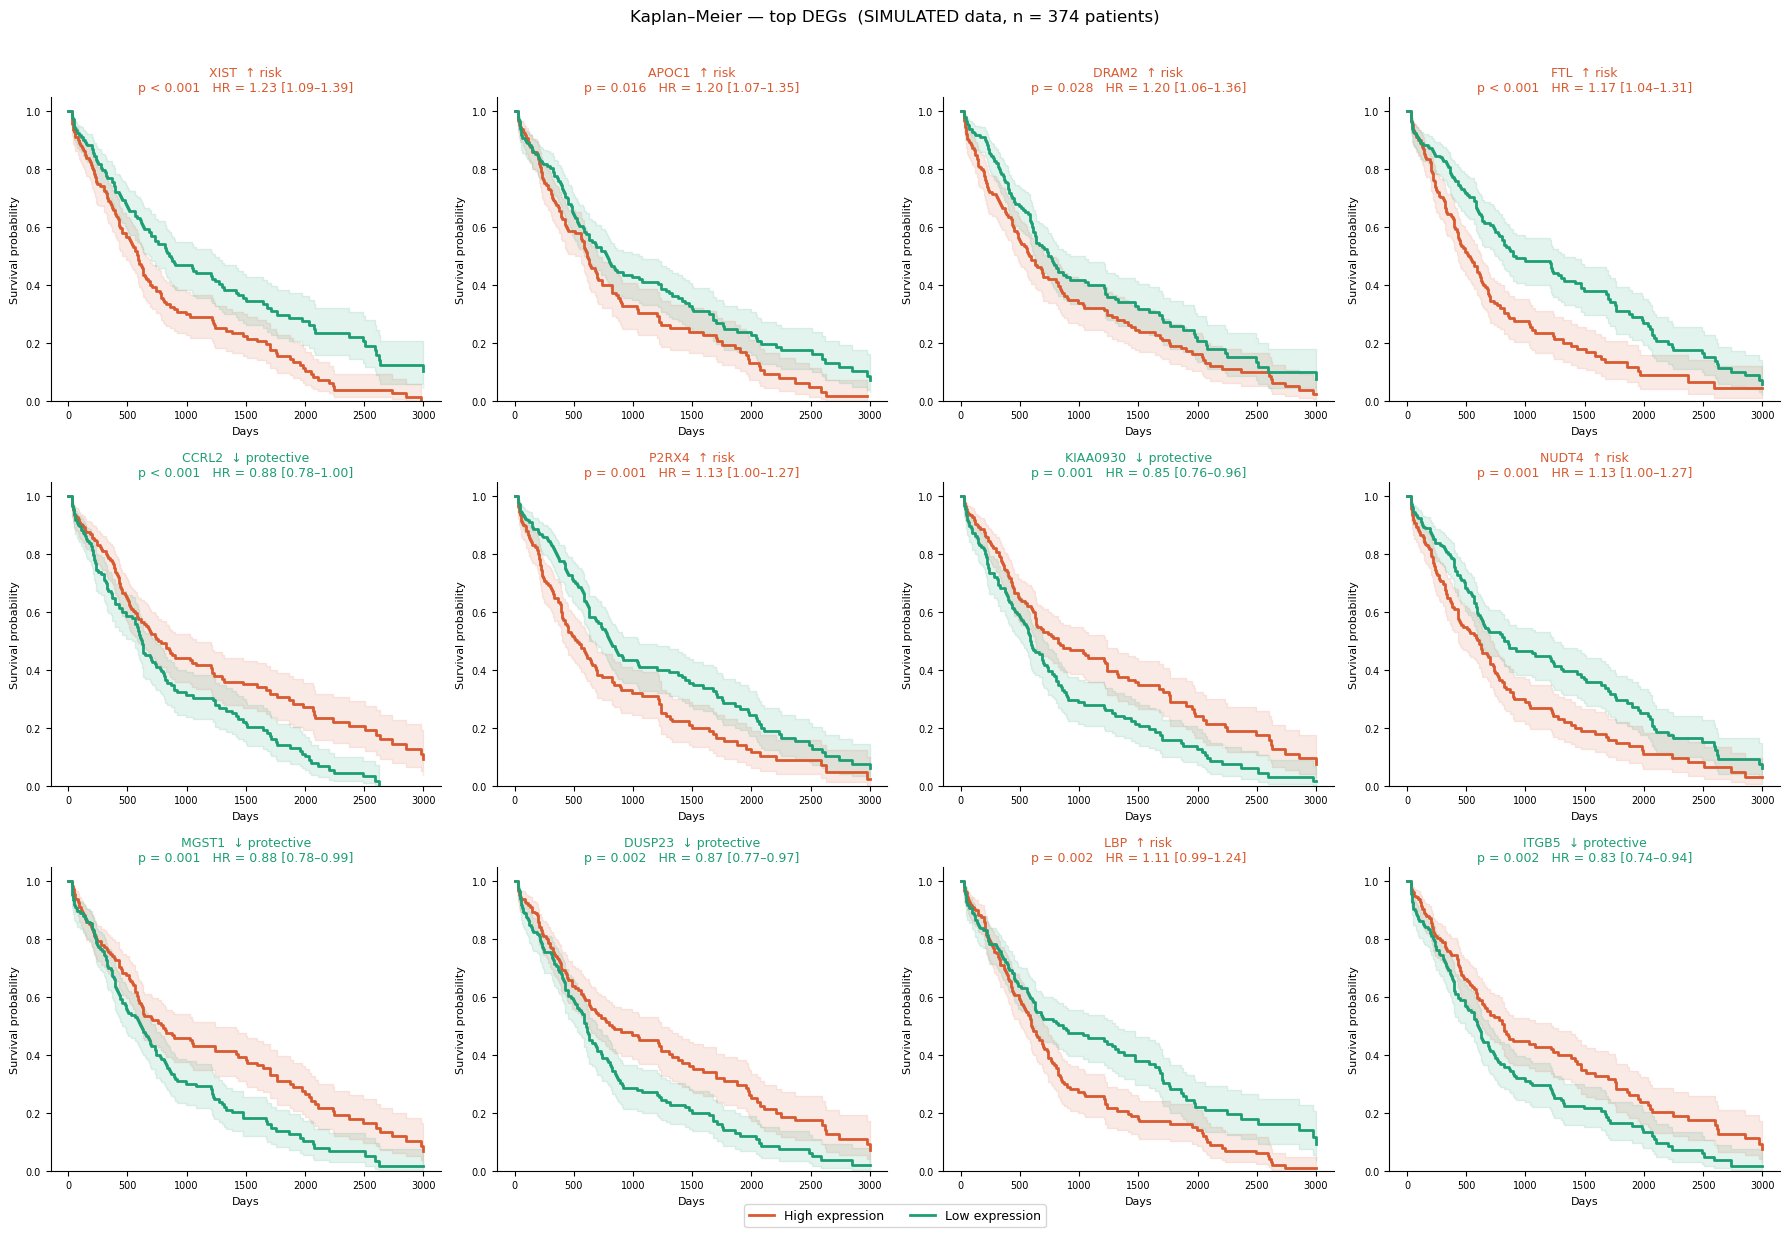

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures/km_plots.png


In [8]:
top_genes = surv_filtered.head(TOP_KM).gene.tolist()
if len(top_genes) < TOP_KM:
    extras = (surv_df[~surv_df.gene.isin(top_genes)]
              .head(TOP_KM - len(top_genes)).gene.tolist())
    top_genes += extras

fig = plot_km_grid(top_genes, surv_df, merged, is_simulated=is_sim)
fig.savefig(FIGURES_DIR / "km_plots.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR}/km_plots.png")

## Cox proportional-hazards forest plot

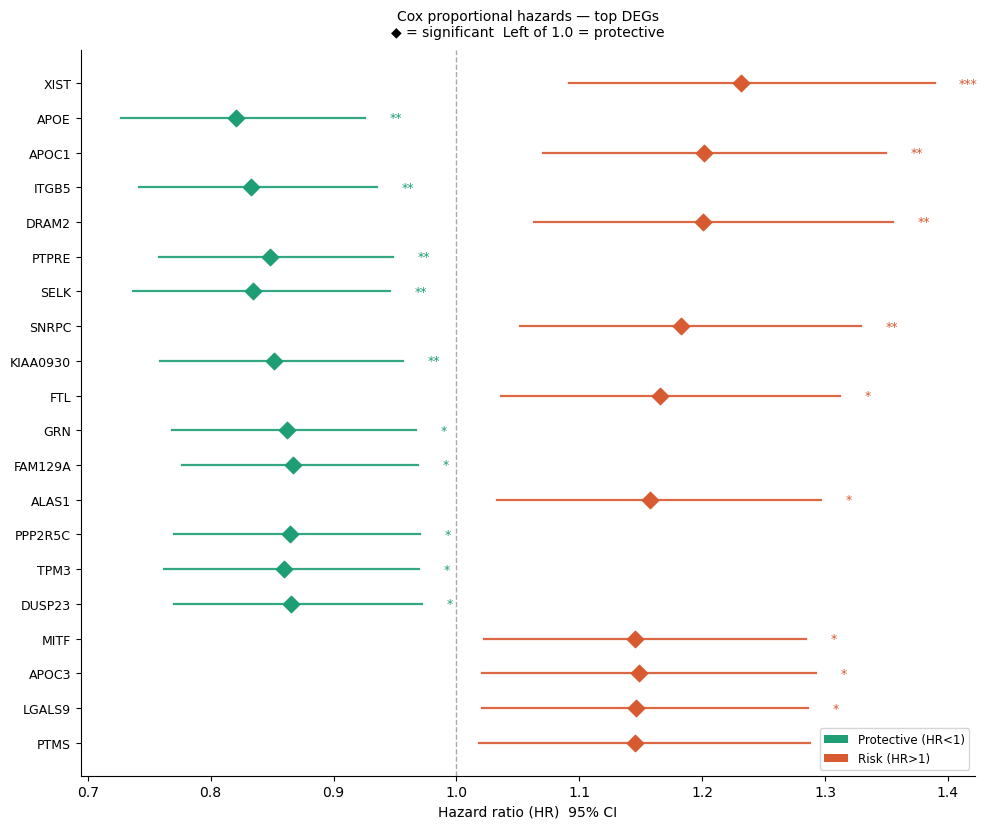

Saved: C:\Users\shoko\OneDrive\Desktop\project\HCC_DD\results\figures/cox_forest_plot.png


In [9]:
fig, _ = plot_cox_forest(surv_df, top_n=20, cox_p_thresh=COX_P_THRESH)
fig.savefig(FIGURES_DIR / "cox_forest_plot.png", dpi=200, bbox_inches="tight")
plt.show()
print(f"Saved: {FIGURES_DIR}/cox_forest_plot.png")

## Export

In [10]:
surv_df["prognosis"] = surv_df.HR.apply(
    lambda h: "protective" if pd.notna(h) and h < 1
              else "risk" if pd.notna(h) else "")
surv_df.to_csv(TABLES_DIR / "survival_results.csv", index=False)

filt_cols = ["gene","logrank_p","cox_p","HR","HR_CI_low","HR_CI_high",
             "log2FC","regulation","prognosis"]
surv_filtered[[c for c in filt_cols if c in surv_filtered.columns]].to_csv(
    TABLES_DIR / "survival_filtered_genes.csv", index=False)

print(f"Saved: survival_results.csv          ({len(surv_df)} genes)")
print(f"Saved: survival_filtered_genes.csv   ({len(surv_filtered)} genes  →  GNN input)")

Saved: survival_results.csv          (1385 genes)
Saved: survival_filtered_genes.csv   (3 genes  →  GNN input)
